In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [ ]:
#Load Dataset
import pandas as pd

df = pd.read_csv(r"D:\F C U L univeristy\University\Level 3\Second Term\Projects Decodelap\Data Science Project 2\data\raw\creditcard.csv")

print(df.columns.tolist())
print(df.head())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [8]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
#Missing Values
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [ ]:
#Duplicate Rows
duplicates = df.duplicated().sum()

print("Duplicate Rows =", duplicates)

Duplicate Rows = 1081


In [ ]:
#Remove Duplicates
df.drop_duplicates(inplace=True)

print(df.shape)

(283726, 31)


In [ ]:
#Class Distribution
df["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

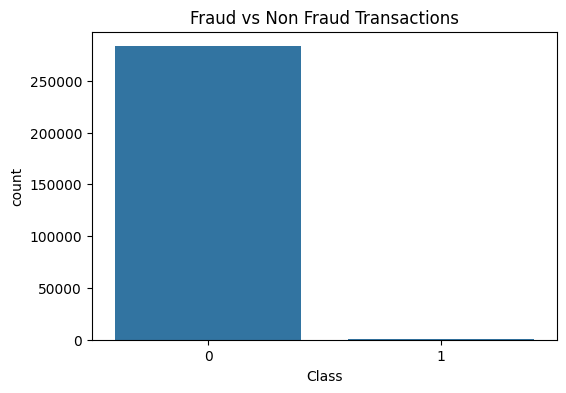

In [ ]:
#Visualize Class Distribution
plt.figure(figsize=(6,4))

sns.countplot(x="Class", data=df)

plt.title("Fraud vs Non Fraud Transactions")

plt.show()

In [ ]:
#Percentage of Fraud Cases
fraud_percentage = (
    df["Class"].value_counts(normalize=True) * 100
)

print(fraud_percentage)

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


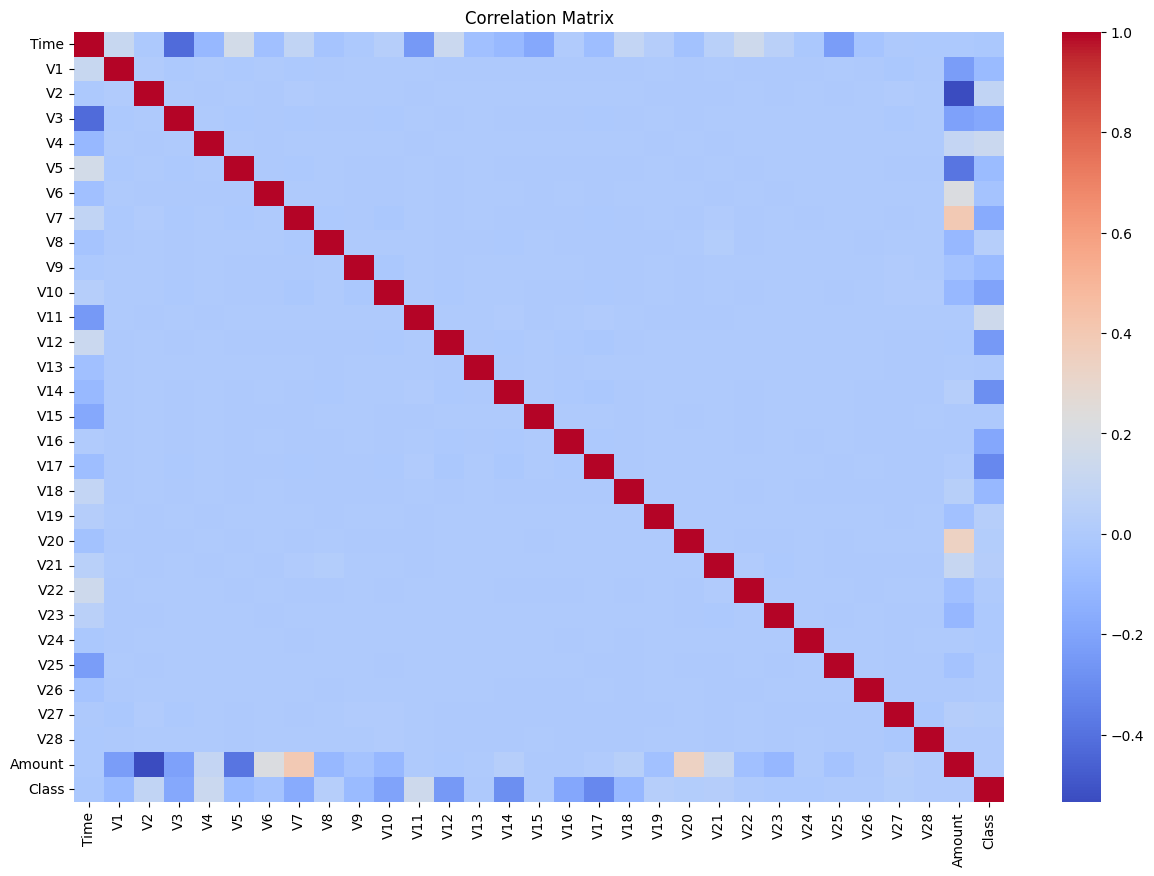

In [ ]:
#Correlation Matrix
plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
#Feature-Target Split
X = df.drop("Class", axis=1)

y = df["Class"]

In [ ]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
#Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
#Apply SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE
Class
0    226602
1    226602
Name: count, dtype: int64


In [ ]:
#Logistic Regression
lr = LogisticRegression()

lr.fit(
    X_train_smote,
    y_train_smote
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
#Logistic Predictions
y_pred_lr = lr.predict(X_test)

y_prob_lr = lr.predict_proba(X_test)[:,1]

In [ ]:
# Logistic Evaluation
print("Precision:",
      precision_score(y_test,y_pred_lr))

print("Recall:",
      recall_score(y_test,y_pred_lr))

print("ROC AUC:",
      roc_auc_score(y_test,y_prob_lr))

Precision: 0.053035143769968054
Recall: 0.8736842105263158
ROC AUC: 0.9626184886409772


In [ ]:
#Logistic Classification Report
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



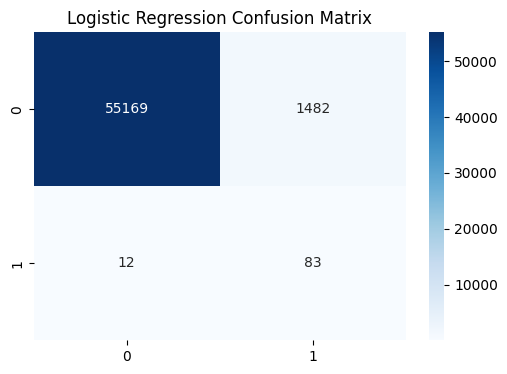

In [ ]:
#Logistic Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [ ]:
#Random Forest Classifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train_smote,
    y_train_smote
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# Random Forest Prediction
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1
)

grid.fit(
    X_train_smote,
    y_train_smote
)

print("Best Parameters:")
print(grid.best_params_)

best_rf = grid.best_estimator_

Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
#Random Forest Predictions
y_pred_rf = best_rf.predict(X_test)

y_prob_rf = best_rf.predict_proba(X_test)[:,1]

In [ ]:
# Random Forest Evaluation

print("Precision:",
      precision_score(y_test,y_pred_rf))

print("Recall:",
      recall_score(y_test,y_pred_rf))

print("ROC AUC:",
      roc_auc_score(y_test,y_prob_rf))

Precision: 0.9113924050632911
Recall: 0.7578947368421053
ROC AUC: 0.9730811645448725


In [ ]:
#Random Forest Report
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.76      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746



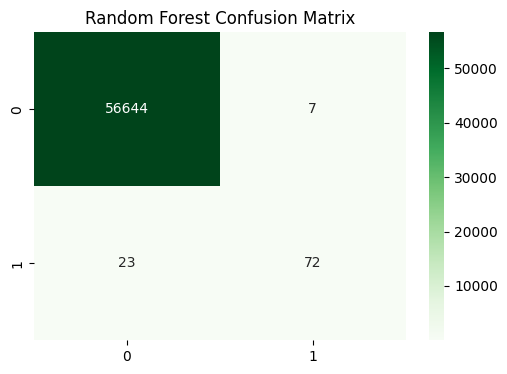

In [ ]:
#Random Forest Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")

plt.show()

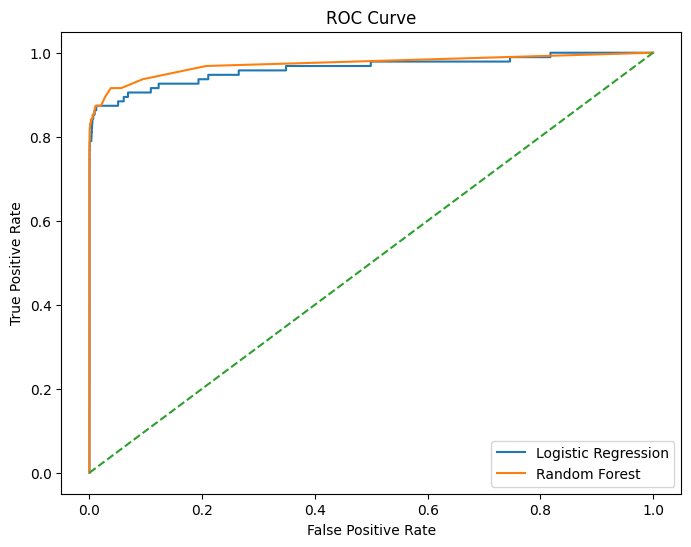

In [ ]:
#ROC Curve Comparison
fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_lr
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label="Logistic Regression"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label="Random Forest"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
# Comparison Table
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],

    "Precision":[
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_rf)
    ],

    "Recall":[
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_rf)
    ],

    "ROC_AUC":[
        roc_auc_score(y_test,y_prob_lr),
        roc_auc_score(y_test,y_prob_rf)
    ]
})

results

,Model,Precision,Recall,ROC_AUC
0,Logistic Regression,0.053035,0.873684,0.962618
1,Random Forest,0.911392,0.757895,0.973081


In [ ]:
#Save Clean Dataset
df.to_csv(
    "cleaned_dataset.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [ ]:
#Save Model
import joblib

joblib.dump(
    rf,
    "fraud_detection_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [35]:
print("Best Model: Random Forest")

print("Precision:",
      precision_score(y_test,y_pred_rf))

print("Recall:",
      recall_score(y_test,y_pred_rf))

print("ROC-AUC:",
      roc_auc_score(y_test,y_prob_rf))

Best Model: Random Forest
Precision: 0.9113924050632911
Recall: 0.7578947368421053
ROC-AUC: 0.9730811645448725


In [ ]:
# Test Set
idx = 10

sample = X_test[idx].reshape(1, -1)

prediction = best_rf.predict(sample)[0]
probability = best_rf.predict_proba(sample)[0][1]

print("Prediction:", prediction)
print("Fraud Probability:", probability)

if prediction == 1:
    print("🚨 Fraud Transaction")
else:
    print("✅ Normal Transaction")

Prediction: 0
Fraud Probability: 0.0
✅ Normal Transaction


In [ ]:
# Test Set
fraud_indices = np.where(y_test == 1)[0]

idx = fraud_indices[0]

sample = X_test[idx].reshape(1, -1)

pred = best_rf.predict(sample)[0]
prob = best_rf.predict_proba(sample)[0][1]

print("Actual Class:", y_test.iloc[idx])
print("Predicted Class:", pred)
print(f"Fraud Probability: {prob:.4f}")

if pred == 1:
    print("🚨 Fraud Transaction")
else:
    print("✅ Normal Transaction")

Actual Class: 1
Predicted Class: 1
Fraud Probability: 0.9750
🚨 Fraud Transaction
